<center>
<img src="https://i.ibb.co/b3T5hkz/logo.png" alt="logo" border="0" width=600>


---
## 01. Generative Adversary Neural Networks (GANNs)


Eduard Larrañaga (ealarranaga@unal.edu.co)

---

### Abstract

In this notebook we will present a simple example of a Generative Adversary Neural Network (GANN).

---

---

## Generative Adversary Neural Networks (GANNs)

As an example of a Generative Adversary Neural Network (GANN), we will implement an algorithm that generates pairs of points with the form $(x,y)$ modelling the $\sin$ function.


The first step is to load the needed libraries and to define a seed for random numbers in [pytorch](https://pyTorch.org).


In [1]:
import torch
from torch import nn

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
%matplotlib inline

torch.manual_seed(413)

Now, we will generate the training fata by defining pairs fo numbers with the form $(x,y)$ where x will be a random number in the interval $[0,2\pi)$ and $y = \sin x$. The data will be given as a tensor with $1024 \times 2$ entries,


In [2]:
train_data_length = 1024
train_data = torch.zeros((train_data_length, 2))
train_data[:, 0] = 2 * np.pi * torch.rand(train_data_length)
train_data[:, 1] = torch.sin(train_data[:, 0])

train_labels = torch.zeros(train_data_length)
train_set = [(train_data[i], train_labels[i]) for i in range(train_data_length)]

In [3]:
train_set[0:10]

[(tensor([0.8598, 0.7577]), tensor(0.)),
 (tensor([ 4.5428, -0.9857]), tensor(0.)),
 (tensor([ 3.5860, -0.4299]), tensor(0.)),
 (tensor([2.3533, 0.7091]), tensor(0.)),
 (tensor([ 5.9962, -0.2831]), tensor(0.)),
 (tensor([ 6.0310, -0.2495]), tensor(0.)),
 (tensor([ 6.2222, -0.0610]), tensor(0.)),
 (tensor([ 3.3219, -0.1793]), tensor(0.)),
 (tensor([2.2024, 0.8071]), tensor(0.)),
 (tensor([3.0591, 0.0824]), tensor(0.))]

Note that the train set includes a column with labels. However, the GANN is an unsupervised algorithm and therefore this column won't be used.

The training data is plotted in the following figure,

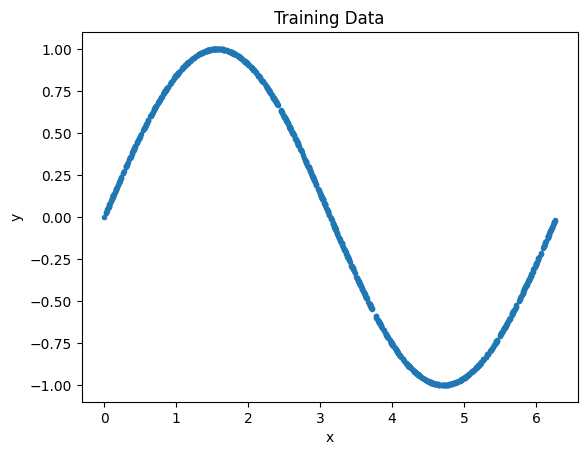

In [4]:
plt.figure()
plt.plot(train_data[:, 0], train_data[:, 1], ".")
plt.xlabel(r'x')
plt.ylabel(r'y')
plt.title('Training Data')
plt.show()

To use this data in `pyTorch`, we need to defin a data loader using the function [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html) with a batch size of 32 elements and shuffling the elements in the dataset.

In [5]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True
)

## The Neural Networks

We need to implement the Neural Networks (NN).

### The Discriminator

First, the Discriminator NN will be an object of the [nn.Module()](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) class with a [sequential model](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html). The layers will be created with the following structure,

- Linear layer with 2 inputs, 256 outputs and a ReLU activation.
- Dropout (30%) layer to prevent overfitting
- Linear layer with 256 inputs, 128 outputs and a ReLU activation.
- Dropout (30%) layer to prevent overfitting
- Linear layer with 128 inputs, 64 outputs and a ReLU activation.
- Dropout (30%) layer to prevent overfitting
- Linear layer with 64 inputs, 1 outputs and a sigmoid activation in order to represent a probability.

We also define the method `.forward()` that calculates the output of the model using the input 2-dimensional tensor `x`.


In [6]:
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(nn.Linear(2, 256),
                               nn.ReLU(),
                               nn.Dropout(0.3),
                               nn.Linear(256, 128),
                               nn.ReLU(),
                               nn.Dropout(0.3),
                               nn.Linear(128, 64),
                               nn.ReLU(),
                               nn.Dropout(0.3),
                               nn.Linear(64, 1),
                               nn.Sigmoid(),)
  def forward(self, x):
    output = self.model(x)
    return output

discriminator = Discriminator()

### The Generator

The Generator NN will also be an object of the [nn.Module()](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) class with a [sequential model](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html). This network receives an input consisting of two random points and will produce a 2-dimensional output resembling the $\sin$ function. The layers will be created with the following structure,

- Linear layer with 2 inputs, 16 outputs and a ReLU activation.
- Linear layer with 16 inputs, 32 outputs and a ReLU activation.
- Linear layer with 32 inputs and 2 outputs. No activation is introduced for this layer.

We also define the method `.forward()` that calculates the genrated output from the input 2-dimensional tensor `x`.


In [7]:
class Generator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(nn.Linear(2, 16),
                               nn.ReLU(),
                               nn.Linear(16, 32),
                               nn.ReLU(),
                               nn.Linear(32, 2),)
  def forward(self, x):
    output = self.model(x)
    return output

generator = Generator()

### Optimizer

We will use the [torch.optim.Adam()](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) optimizer for both networks with a learning rate of $0.001$. Note that the ADAM optimizer access the parameters of the neural networks through the method `.parameters()`.

In [9]:
lr = 0.001

optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

## Training the Model

We will train the model through 300 epochs and the loss function will be the Binary Cross Entropy, [nn.BCELoss()](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html).

Next, we implement a double `for` loop to train the networks. The outer loop counts the epochs while the inner loop counts the batches in each epoch. Note that for GANs, the parameters of both, the discriminator and the generator, are updated at each iteration.

We first proceed with the training of the discriminator in two steps:

* Using the Generator, we obtain the `generated_samples` and these are concatenated with the `real_samples` using the [torch.cat( )](https://pytorch.org/docs/stable/generated/torch.cat.html) function. Similarly, we concatenate the `real_samples_labels` (ones) and the `generated_samples_labels` (zeros).

* The training of the discriminator begins with a clear of the gradients (this is necessary in `pyTorch` in order to avoid an accumulation of values). Then, we calculate the output and evaluate the loss function for all the samples comparing with all the labels.
The method `.backward()` calaculates the gradients and the `.step()` updates the parameters of the discriminator.

The training of the generator is done in two steps:

*  First, we create random data points for the latent space and generate the samples.

* After clearing the gradients, we apply the generated samples to the discriminator and the obtained outputs are evaluated with the loss function by comparing with the real labels. Using the methods `.backward()` and `.step()` we calaculate the gradients and update the parameters of the generator.

Finally, we print some training information.

In [10]:

def training(num_epochs, loss_function):
  history = []
  for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):

      # Data for training the discriminator
      real_samples_labels = torch.ones((batch_size, 1))

      latent_space_samples = torch.randn((batch_size, 2))
      generated_samples = generator(latent_space_samples)
      generated_samples_labels = torch.zeros((batch_size, 1))

      all_samples = torch.cat((real_samples, generated_samples))
      all_samples_labels = torch.cat(
                                  (real_samples_labels, generated_samples_labels)
                                    )

      # Training the discriminator
      discriminator.zero_grad()
      output_discriminator = discriminator(all_samples)
      loss_discriminator = loss_function(output_discriminator, all_samples_labels)
      loss_discriminator.backward()
      optimizer_discriminator.step()

      # Data for training the generator
      latent_space_samples = torch.randn((batch_size, 2))
      generated_samples = generator(latent_space_samples)

      # Training the generator
      generator.zero_grad()
      output_discriminator_generated = discriminator(generated_samples)
      loss_generator = loss_function(
                            output_discriminator_generated, real_samples_labels
                                    )
      loss_generator.backward()
      optimizer_generator.step()

      # Show loss
      if epoch % 10 == 0 and n == batch_size - 1:
        print(f"Epoch: {epoch} Loss D.: {loss_discriminator}")
        print(f"Epoch: {epoch} Loss G.: {loss_generator}")
        im = image_plot()
        history.append(im)

  return history



def image_plot():
  plot_samples = torch.randn(100, 2)
  plot_generated_samples = generator(plot_samples)
  return plot_generated_samples.detach()



num_epochs = 500
loss_function = nn.BCELoss()

history = training(num_epochs, loss_function)

Epoch: 0 Loss D.: 0.27129629254341125
Epoch: 0 Loss G.: 1.8109384775161743
Epoch: 10 Loss D.: 0.7056739330291748
Epoch: 10 Loss G.: 0.8332881927490234
Epoch: 20 Loss D.: 0.6338759064674377
Epoch: 20 Loss G.: 0.88649982213974
Epoch: 30 Loss D.: 0.611823558807373
Epoch: 30 Loss G.: 0.8933645486831665
Epoch: 40 Loss D.: 0.647587239742279
Epoch: 40 Loss G.: 0.7701697945594788
Epoch: 50 Loss D.: 0.5300517082214355
Epoch: 50 Loss G.: 1.0898607969284058
Epoch: 60 Loss D.: 0.6298249959945679
Epoch: 60 Loss G.: 0.7074029445648193
Epoch: 70 Loss D.: 0.6471057534217834
Epoch: 70 Loss G.: 0.8513007164001465
Epoch: 80 Loss D.: 0.5871260762214661
Epoch: 80 Loss G.: 0.8487964272499084
Epoch: 90 Loss D.: 0.604017972946167
Epoch: 90 Loss G.: 1.0155439376831055
Epoch: 100 Loss D.: 0.5932257175445557
Epoch: 100 Loss G.: 1.0459245443344116
Epoch: 110 Loss D.: 0.7278979420661926
Epoch: 110 Loss G.: 0.7445389628410339
Epoch: 120 Loss D.: 0.6449288129806519
Epoch: 120 Loss G.: 0.8005744814872742
Epoch: 130 L

## Probing the Neural Network

Once the neural network is trained, we will probe its results by considering a latent space with 100 random samples.

In [11]:
latent_space_samples = torch.randn(100, 2)
generated_samples = generator(latent_space_samples)

The generated samples are plotted to see the fitness of the network. Note the use of the method `.detach()` to extract the data from the resulting tensor.

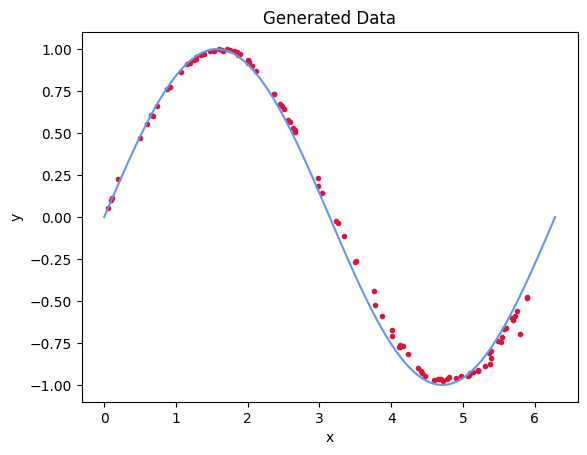

In [12]:
generated_samples = generated_samples.detach()

xx = np.linspace(0,2*np.pi,100)

plt.figure()
plt.plot(generated_samples[:, 0], generated_samples[:, 1], '.', color='crimson')
plt.plot(xx, np.sin(xx), color='cornflowerblue')
plt.xlabel(r'x')
plt.ylabel(r'y')
plt.title('Generated Data')
plt.show()

In [13]:
# Set up the figure, the axis, and the plot element we want to animate
fig, ax = plt.subplots()
xx = np.linspace(0,2*np.pi,100)
ax.plot(xx, np.sin(xx), color='cornflowerblue')
ax.set_xlim((0, 8))
ax.set_ylim((-1.1, 1.1))
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
plt.title('Generated Data')

line, = ax.plot([], [], '.', color='crimson')
title = ax.text(6,0.85, "")

# Define the initialization function, which plots the background of each frame
def init():
    line.set_data([], [])
    #title.set_data([])
    return (line,)

def animate(i):
    #step = int(len(tgrid)/200)
    # We take only some of the frames (given by 50*i)
    line.set_data(history[i][:,0], history[i][:,1])
    title.set_text(f'Epoch = {10*i}')
    return (line,)

anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=len(history), interval=150,  # duration of 20 ms each
                               blit=True)

HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.